In [1]:
# Cell 1: Initialize Phase 17

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

PROJECT_DIR = Path(
    r"C:\Users\ADMIN\FinGraph-Sentinel"
)

DATA_DIR = PROJECT_DIR / "data"
RESULTS_DIR = DATA_DIR / "results"

PHASE17_DIR = RESULTS_DIR / "phase17"

PHASE17_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("Project directory:", PROJECT_DIR)
print("Phase 17 directory:", PHASE17_DIR)
print("Phase 17 initialized successfully.")

Project directory: C:\Users\ADMIN\FinGraph-Sentinel
Phase 17 directory: C:\Users\ADMIN\FinGraph-Sentinel\data\results\phase17
Phase 17 initialized successfully.


In [2]:
# Cell 2: Load the Phase 14 source dataset

phase14_path = (
    RESULTS_DIR
    / "phase14"
    / "multi_signal_risk_validation.csv"
)

print("File exists:", phase14_path.exists())
print("File path:", phase14_path)

if not phase14_path.exists():
    raise FileNotFoundError(
        f"Dataset not found: {phase14_path}"
    )

validation_df = pd.read_csv(phase14_path)

validation_df["date"] = pd.to_datetime(
    validation_df["date"]
)

validation_df = (
    validation_df
    .sort_values("date")
    .reset_index(drop=True)
)

print("Dataset shape:", validation_df.shape)
print("Start date:", validation_df["date"].min())
print("End date:", validation_df["date"].max())

display(validation_df.head())

File exists: True
File path: C:\Users\ADMIN\FinGraph-Sentinel\data\results\phase14\multi_signal_risk_validation.csv
Dataset shape: (1180, 9)
Start date: 2021-11-12 00:00:00
End date: 2026-07-16 00:00:00


,date,degree,betweenness,pagerank,systemic_risk_score,multi_signal_risk_score,risk_percentile,exploratory_risk_category,future_stress_event
0,2021-11-12,0.585833,0.392917,0.795833,0.566667,0.585312,62.250000,Moderate,0
1,2021-11-12,0.585833,0.817917,0.809167,0.596667,0.702396,80.916667,High,0
2,2021-11-12,0.585833,0.817917,0.868333,0.605000,0.719271,82.416667,High,0
3,2021-11-12,0.109583,0.392917,0.070833,0.070833,0.161042,7.083333,Lower,0
4,2021-11-12,0.315000,0.392917,0.775417,0.342083,0.456354,39.875000,Lower,0


In [3]:
# Cell 3: Create date-level aggregated dataset

date_level_df = (
    validation_df
    .groupby("date")
    .agg(
        degree=("degree", "mean"),
        betweenness=("betweenness", "mean"),
        pagerank=("pagerank", "mean"),
        systemic_risk_score=("systemic_risk_score", "mean"),
        multi_signal_risk_score=(
            "multi_signal_risk_score",
            "mean"
        ),
        risk_percentile=("risk_percentile", "mean"),
        total_companies=(
            "future_stress_event",
            "count"
        ),
        stress_events=(
            "future_stress_event",
            "sum"
        )
    )
    .reset_index()
    .sort_values("date")
    .reset_index(drop=True)
)

date_level_df["date_stress_event"] = (
    date_level_df["stress_events"] > 0
).astype(int)

print("Date-level dataset shape:", date_level_df.shape)

display(date_level_df.head())

Date-level dataset shape: (118, 10)


,date,degree,betweenness,pagerank,systemic_risk_score,multi_signal_risk_score,risk_percentile,total_companies,stress_events,date_stress_event
0,2021-11-12,0.377958,0.520417,0.545250,0.366333,0.452490,44.075000,10,0,0
1,2021-11-29,0.393958,0.477917,0.541625,0.380458,0.448490,42.845833,10,0,0
2,2021-12-13,0.393958,0.477917,0.536833,0.379167,0.446969,42.479167,10,0,0
3,2021-12-28,0.396792,0.477917,0.561042,0.388125,0.455969,44.658333,10,10,1
4,2022-01-11,0.396792,0.477917,0.561375,0.388042,0.456031,44.679167,10,0,0


In [4]:
# Cell 4: Create temporal features

signal_columns = [
    "degree",
    "betweenness",
    "pagerank",
    "systemic_risk_score",
    "multi_signal_risk_score",
    "risk_percentile"
]

feature_df = date_level_df.copy()

for signal in signal_columns:

    # Daily change
    feature_df[f"{signal}_change"] = (
        feature_df[signal].diff()
    )

    # Previous 3-observation rolling mean
    feature_df[f"{signal}_rolling_mean_3"] = (
        feature_df[signal]
        .rolling(window=3, min_periods=3)
        .mean()
        .shift(1)
    )

    # Previous 3-observation rolling standard deviation
    feature_df[f"{signal}_rolling_std_3"] = (
        feature_df[signal]
        .rolling(window=3, min_periods=3)
        .std()
        .shift(1)
    )

    # Rolling z-score
    rolling_mean = feature_df[
        f"{signal}_rolling_mean_3"
    ]

    rolling_std = feature_df[
        f"{signal}_rolling_std_3"
    ].replace(0, np.nan)

    feature_df[f"{signal}_zscore_3"] = (
        (feature_df[signal] - rolling_mean)
        / rolling_std
    )

feature_df = feature_df.replace(
    [np.inf, -np.inf],
    np.nan
)

model_df = (
    feature_df
    .dropna()
    .sort_values("date")
    .reset_index(drop=True)
)

print("Feature dataset shape:", feature_df.shape)
print("Model dataset shape:", model_df.shape)
print("Remaining missing values:", model_df.isna().sum().sum())

display(model_df.head())

Feature dataset shape: (118, 34)
Model dataset shape: (103, 34)
Remaining missing values: 0


,date,degree,betweenness,pagerank,systemic_risk_score,multi_signal_risk_score,risk_percentile,total_companies,stress_events,date_stress_event,...,systemic_risk_score_rolling_std_3,systemic_risk_score_zscore_3,multi_signal_risk_score_change,multi_signal_risk_score_rolling_mean_3,multi_signal_risk_score_rolling_std_3,multi_signal_risk_score_zscore_3,risk_percentile_change,risk_percentile_rolling_mean_3,risk_percentile_rolling_std_3,risk_percentile_zscore_3
0,2021-12-28,0.396792,0.477917,0.561042,0.388125,0.455969,44.658333,10,10,1,...,0.007809,1.639856,0.009000,0.449316,0.002852,2.332931,2.179167,43.133333,0.835861,1.824467
1,2022-02-09,0.540458,0.620792,0.495292,0.530125,0.546667,54.916667,10,10,1,...,0.056460,1.938440,0.027219,0.477149,0.036632,1.897739,3.370833,46.961111,3.970500,2.003666
2,2022-02-24,0.652333,0.632667,0.504458,0.623042,0.603125,62.487500,10,0,0,...,0.072706,2.132252,0.056458,0.507382,0.046507,2.058688,7.570833,50.380556,5.217280,2.320547
3,2022-03-10,0.675750,0.586417,0.500292,0.656375,0.604708,62.079167,10,0,0,...,0.070007,1.571658,0.001583,0.556413,0.042681,1.131524,-0.408333,56.316667,5.603572,1.028362
4,2022-03-24,0.719292,0.535417,0.497708,0.699042,0.612865,64.441667,10,0,0,...,0.065426,1.465175,0.008156,0.584833,0.033063,0.847819,2.362500,59.827778,4.258045,1.083570


In [5]:
# Cell 5: Save Phase 17 modeling dataset

phase17_model_path = (
    PHASE17_DIR
    / "phase17_modeling_dataset.csv"
)

model_df.to_csv(
    phase17_model_path,
    index=False
)

print("Saved modeling dataset to:")
print(phase17_model_path)

print("Saved dataset shape:", model_df.shape)

Saved modeling dataset to:
C:\Users\ADMIN\FinGraph-Sentinel\data\results\phase17\phase17_modeling_dataset.csv
Saved dataset shape: (103, 34)


In [6]:
# Cell 6: Data Quality Audit

print("========== DATA QUALITY AUDIT ==========")

print("Dataset shape:", model_df.shape)

print("\nDate range:")
print("Start:", model_df["date"].min())
print("End:", model_df["date"].max())

print("\nMissing values:")
display(
    model_df.isna().sum()
    .sort_values(ascending=False)
    .head(15)
)

print("\nDuplicate dates:", model_df["date"].duplicated().sum())

print("\nNumeric summary:")
display(
    model_df[
        [
            "degree",
            "betweenness",
            "pagerank",
            "systemic_risk_score",
            "multi_signal_risk_score",
            "risk_percentile"
        ]
    ].describe().T
)

========== DATA QUALITY AUDIT ==========
Dataset shape: (103, 34)

Date range:
Start: 2021-12-28 00:00:00
End: 2026-07-16 00:00:00

Missing values:


date                       0
degree                     0
betweenness                0
pagerank                   0
systemic_risk_score        0
multi_signal_risk_score    0
risk_percentile            0
total_companies            0
stress_events              0
date_stress_event          0
degree_change              0
degree_rolling_mean_3      0
degree_rolling_std_3       0
degree_zscore_3            0
betweenness_change         0
dtype: int64


Duplicate dates: 0

Numeric summary:


,count,mean,std,min,25%,50%,75%,max
degree,103.0,0.521063,0.233600,0.150667,0.331354,0.453708,0.724625,0.938333
betweenness,103.0,0.508713,0.070934,0.392917,0.444854,0.503042,0.562583,0.677750
pagerank,103.0,0.498183,0.027536,0.385583,0.479896,0.498292,0.514958,0.561042
systemic_risk_score,103.0,0.517035,0.210434,0.266417,0.336792,0.430958,0.706771,0.892667
multi_signal_risk_score,103.0,0.511248,0.118017,0.304479,0.417312,0.483333,0.623974,0.707844
risk_percentile,103.0,51.346440,15.590390,29.391667,38.016667,46.512500,64.854167,78.458333


In [7]:
# Cell 7: Stress Event Label Audit

print("========== EVENT LABEL AUDIT ==========")

print("Date-level observations:", len(date_level_df))

print("\nTotal stress events:")
print(date_level_df["stress_events"].sum())

print("\nDates containing stress events:")
print(
    date_level_df["date_stress_event"]
    .value_counts()
    .sort_index()
)

print("\nStress events by date:")
display(
    date_level_df[
        date_level_df["date_stress_event"] == 1
    ][
        [
            "date",
            "stress_events",
            "total_companies",
            "date_stress_event"
        ]
    ]
)

print("\nEvent rate:")
event_rate = (
    date_level_df["date_stress_event"].mean() * 100
)

print(f"{event_rate:.2f}%")

========== EVENT LABEL AUDIT ==========
Date-level observations: 118

Total stress events:
160

Dates containing stress events:
date_stress_event
0    102
1     16
Name: count, dtype: int64

Stress events by date:


,date,stress_events,total_companies,date_stress_event
3,2021-12-28,10,10,1
5,2022-01-26,10,10,1
6,2022-02-09,10,10,1
10,2022-04-07,10,10,1
11,2022-04-22,10,10,1
12,2022-05-06,10,10,1
13,2022-05-20,10,10,1
14,2022-06-06,10,10,1
19,2022-08-17,10,10,1
21,2022-09-15,10,10,1



Event rate:
13.56%


In [8]:
# Cell 8: Chronological Spacing Audit

date_gaps = (
    date_level_df["date"]
    .sort_values()
    .diff()
    .dt.days
)

print("========== DATE GAP AUDIT ==========")

print("Minimum gap:", date_gaps.min(), "days")
print("Maximum gap:", date_gaps.max(), "days")
print("Median gap:", date_gaps.median(), "days")

print("\nGap distribution:")
display(date_gaps.describe())

print("\nLargest gaps:")
display(
    date_gaps
    .sort_values(ascending=False)
    .head(10)
)

========== DATE GAP AUDIT ==========
Minimum gap: 14.0 days
Maximum gap: 18.0 days
Median gap: 14.0 days

Gap distribution:


count    117.000000
mean      14.589744
std        0.975156
min       14.000000
25%       14.000000
50%       14.000000
75%       15.000000
max       18.000000
Name: date, dtype: float64


Largest gaps:


29     18.0
79     18.0
54     18.0
14     17.0
1      17.0
86     17.0
64     17.0
110    17.0
102    17.0
39     17.0
Name: date, dtype: float64

In [9]:
# Cell 9: Save Data Quality Audit

audit_summary = pd.DataFrame({
    "metric": [
        "model_rows",
        "model_columns",
        "date_level_rows",
        "date_start",
        "date_end",
        "total_stress_events",
        "stress_event_dates",
        "event_rate_percent",
        "missing_values",
        "duplicate_dates"
    ],
    "value": [
        len(model_df),
        len(model_df.columns),
        len(date_level_df),
        str(date_level_df["date"].min()),
        str(date_level_df["date"].max()),
        int(date_level_df["stress_events"].sum()),
        int(date_level_df["date_stress_event"].sum()),
        round(event_rate, 4),
        int(model_df.isna().sum().sum()),
        int(model_df["date"].duplicated().sum())
    ]
})

audit_path = PHASE17_DIR / "data_quality_audit.csv"

audit_summary.to_csv(
    audit_path,
    index=False
)

print("Audit saved to:")
print(audit_path)

display(audit_summary)

Audit saved to:
C:\Users\ADMIN\FinGraph-Sentinel\data\results\phase17\data_quality_audit.csv


,metric,value
0,model_rows,103
1,model_columns,34
2,date_level_rows,118
3,date_start,2021-11-12 00:00:00
4,date_end,2026-07-16 00:00:00
5,total_stress_events,160
6,stress_event_dates,16
7,event_rate_percent,13.5593
8,missing_values,0
9,duplicate_dates,0


In [10]:
# Cell 10: Prepare Baseline Modeling Dataset

from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score
)

target_column = "date_stress_event"

candidate_features = [
    "degree_change",
    "betweenness_change",
    "pagerank_change",
    "systemic_risk_score_change",
    "multi_signal_risk_score_change",
    "risk_percentile_change",
    "degree_rolling_mean_3",
    "betweenness_rolling_mean_3",
    "systemic_risk_score_rolling_mean_3",
    "multi_signal_risk_score_rolling_mean_3"
]

available_features = [
    feature
    for feature in candidate_features
    if feature in model_df.columns
]

X = model_df[available_features].copy()
y = model_df[target_column].astype(int).copy()

print("Available features:", available_features)
print("X shape:", X.shape)
print("Target distribution:")
print(y.value_counts())

Available features: ['degree_change', 'betweenness_change', 'pagerank_change', 'systemic_risk_score_change', 'multi_signal_risk_score_change', 'risk_percentile_change', 'degree_rolling_mean_3', 'betweenness_rolling_mean_3', 'systemic_risk_score_rolling_mean_3', 'multi_signal_risk_score_rolling_mean_3']
X shape: (103, 10)
Target distribution:
date_stress_event
0    88
1    15
Name: count, dtype: int64


In [11]:
# Cell 11: Chronological Train-Test Split

split_index = int(len(model_df) * 0.70)

X_train = X.iloc[:split_index].copy()
X_test = X.iloc[split_index:].copy()

y_train = y.iloc[:split_index].copy()
y_test = y.iloc[split_index:].copy()

train_dates = model_df["date"].iloc[:split_index]
test_dates = model_df["date"].iloc[split_index:]

print("Training observations:", len(X_train))
print("Testing observations:", len(X_test))

print("\nTraining period:")
print(train_dates.min(), "to", train_dates.max())

print("\nTesting period:")
print(test_dates.min(), "to", test_dates.max())

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

Training observations: 72
Testing observations: 31

Training period:
2021-12-28 00:00:00 to 2024-12-06 00:00:00

Testing period:
2024-12-20 00:00:00 to 2026-07-16 00:00:00

Training target distribution:
date_stress_event
0    61
1    11
Name: count, dtype: int64

Testing target distribution:
date_stress_event
0    27
1     4
Name: count, dtype: int64


In [12]:
# Cell 12: Baseline Model Comparison

models = {
    "Logistic_Regression": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        (
            "model",
            LogisticRegression(
                max_iter=2000,
                class_weight="balanced",
                random_state=42
            )
        )
    ]),

    "Random_Forest": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        (
            "model",
            RandomForestClassifier(
                n_estimators=300,
                max_depth=4,
                class_weight="balanced",
                random_state=42
            )
        )
    ]),

    "Gradient_Boosting": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        (
            "model",
            GradientBoostingClassifier(
                n_estimators=100,
                learning_rate=0.05,
                max_depth=2,
                random_state=42
            )
        )
    ])
}

baseline_results = []
trained_models = {}

for model_name, model in models.items():

    model.fit(X_train, y_train)

    probabilities = model.predict_proba(X_test)[:, 1]
    predictions = (probabilities >= 0.5).astype(int)

    result = {
        "model": model_name,
        "test_positive_count": int(y_test.sum()),
        "roc_auc": np.nan,
        "pr_auc": np.nan,
        "precision": precision_score(
            y_test,
            predictions,
            zero_division=0
        ),
        "recall": recall_score(
            y_test,
            predictions,
            zero_division=0
        ),
        "f1": f1_score(
            y_test,
            predictions,
            zero_division=0
        )
    }

    if y_test.nunique() >= 2:

        result["roc_auc"] = roc_auc_score(
            y_test,
            probabilities
        )

        result["pr_auc"] = average_precision_score(
            y_test,
            probabilities
        )

    baseline_results.append(result)
    trained_models[model_name] = model

baseline_results_df = pd.DataFrame(baseline_results)

display(
    baseline_results_df.sort_values(
        "pr_auc",
        ascending=False
    )
)

,model,test_positive_count,roc_auc,pr_auc,precision,recall,f1
0,Logistic_Regression,4,0.787037,0.347756,0.285714,0.5,0.363636
2,Gradient_Boosting,4,0.620370,0.207955,0.000000,0.0,0.000000
1,Random_Forest,4,0.629630,0.199405,0.000000,0.0,0.000000


In [13]:
# Cell 13: Save Baseline Comparison Results

baseline_path = (
    PHASE17_DIR
    / "baseline_model_comparison.csv"
)

baseline_results_df.to_csv(
    baseline_path,
    index=False
)

print("Baseline comparison saved to:")
print(baseline_path)

Baseline comparison saved to:
C:\Users\ADMIN\FinGraph-Sentinel\data\results\phase17\baseline_model_comparison.csv


In [14]:
# Cell 14: Define Walk-Forward Evaluation Windows

from sklearn.base import clone

n_observations = len(model_df)

window_definitions = [
    {
        "name": "Window_1",
        "train_end": 0.50,
        "test_end": 0.65
    },
    {
        "name": "Window_2",
        "train_end": 0.60,
        "test_end": 0.75
    },
    {
        "name": "Window_3",
        "train_end": 0.70,
        "test_end": 0.85
    },
    {
        "name": "Window_4",
        "train_end": 0.80,
        "test_end": 1.00
    }
]

print("Total observations:", n_observations)

for window in window_definitions:
    print(window)

Total observations: 103
{'name': 'Window_1', 'train_end': 0.5, 'test_end': 0.65}
{'name': 'Window_2', 'train_end': 0.6, 'test_end': 0.75}
{'name': 'Window_3', 'train_end': 0.7, 'test_end': 0.85}
{'name': 'Window_4', 'train_end': 0.8, 'test_end': 1.0}


In [15]:
# Cell 15: Walk-Forward Model Evaluation

walk_forward_results = []

for window in window_definitions:

    train_end_index = int(
        n_observations * window["train_end"]
    )

    test_end_index = int(
        n_observations * window["test_end"]
    )

    X_train_wf = X.iloc[:train_end_index].copy()
    y_train_wf = y.iloc[:train_end_index].copy()

    X_test_wf = X.iloc[train_end_index:test_end_index].copy()
    y_test_wf = y.iloc[train_end_index:test_end_index].copy()

    for model_name, base_model in models.items():

        current_model = clone(base_model)

        current_model.fit(
            X_train_wf,
            y_train_wf
        )

        probabilities = (
            current_model
            .predict_proba(X_test_wf)[:, 1]
        )

        predictions = (
            probabilities >= 0.5
        ).astype(int)

        result = {
            "window": window["name"],
            "model": model_name,
            "train_size": len(X_train_wf),
            "test_size": len(X_test_wf),
            "train_positive_count": int(y_train_wf.sum()),
            "test_positive_count": int(y_test_wf.sum()),
            "roc_auc": np.nan,
            "pr_auc": np.nan,
            "precision": precision_score(
                y_test_wf,
                predictions,
                zero_division=0
            ),
            "recall": recall_score(
                y_test_wf,
                predictions,
                zero_division=0
            ),
            "f1": f1_score(
                y_test_wf,
                predictions,
                zero_division=0
            )
        }

        if y_test_wf.nunique() >= 2:

            result["roc_auc"] = roc_auc_score(
                y_test_wf,
                probabilities
            )

            result["pr_auc"] = average_precision_score(
                y_test_wf,
                probabilities
            )

        walk_forward_results.append(result)

walk_forward_df = pd.DataFrame(
    walk_forward_results
)

display(
    walk_forward_df.sort_values(
        ["window", "pr_auc"],
        ascending=[True, False]
    )
)

,window,model,train_size,test_size,train_positive_count,test_positive_count,roc_auc,pr_auc,precision,recall,f1
0,Window_1,Logistic_Regression,51,15,11,0,NaN,NaN,0.000000,0.0,0.000000
1,Window_1,Random_Forest,51,15,11,0,NaN,NaN,0.000000,0.0,0.000000
2,Window_1,Gradient_Boosting,51,15,11,0,NaN,NaN,0.000000,0.0,0.000000
4,Window_2,Random_Forest,61,16,11,1,1.000000,1.000000,0.250000,1.0,0.400000
3,Window_2,Logistic_Regression,61,16,11,1,0.800000,0.250000,0.111111,1.0,0.200000
5,Window_2,Gradient_Boosting,61,16,11,1,0.600000,0.125000,0.000000,0.0,0.000000
6,Window_3,Logistic_Regression,72,15,11,4,0.568182,0.374242,0.285714,0.5,0.363636
8,Window_3,Gradient_Boosting,72,15,11,4,0.465909,0.305556,0.000000,0.0,0.000000
7,Window_3,Random_Forest,72,15,11,4,0.340909,0.244643,0.000000,0.0,0.000000
9,Window_4,Logistic_Regression,82,21,15,0,NaN,NaN,0.000000,0.0,0.000000


In [16]:
# Cell 16: Analyze Walk-Forward Stability

stability_summary = (
    walk_forward_df
    .groupby("model")
    .agg(
        mean_roc_auc=("roc_auc", "mean"),
        std_roc_auc=("roc_auc", "std"),
        mean_pr_auc=("pr_auc", "mean"),
        std_pr_auc=("pr_auc", "std"),
        mean_f1=("f1", "mean"),
        std_f1=("f1", "std"),
        evaluated_windows=("window", "count")
    )
    .reset_index()
)

display(
    stability_summary.sort_values(
        "mean_pr_auc",
        ascending=False
    )
)

,model,mean_roc_auc,std_roc_auc,mean_pr_auc,std_pr_auc,mean_f1,std_f1,evaluated_windows
2,Random_Forest,0.670455,0.466048,0.622321,0.534118,0.100000,0.200000,4
1,Logistic_Regression,0.684091,0.163920,0.312121,0.087853,0.140909,0.175888,4
0,Gradient_Boosting,0.532955,0.094817,0.215278,0.127672,0.000000,0.000000,4


In [17]:
# Cell 17: Save Walk-Forward Results

walk_forward_path = (
    PHASE17_DIR
    / "walk_forward_evaluation.csv"
)

stability_path = (
    PHASE17_DIR
    / "walk_forward_stability_summary.csv"
)

walk_forward_df.to_csv(
    walk_forward_path,
    index=False
)

stability_summary.to_csv(
    stability_path,
    index=False
)

print("Saved:", walk_forward_path)
print("Saved:", stability_path)

Saved: C:\Users\ADMIN\FinGraph-Sentinel\data\results\phase17\walk_forward_evaluation.csv
Saved: C:\Users\ADMIN\FinGraph-Sentinel\data\results\phase17\walk_forward_stability_summary.csv


In [18]:
# Cell 18: Feature-Target Relationship Analysis

feature_target_analysis = []

for feature in available_features:

    correlation = model_df[
        [feature, target_column]
    ].corr().iloc[0, 1]

    feature_target_analysis.append({
        "feature": feature,
        "target_correlation": correlation,
        "absolute_correlation": abs(correlation)
    })

feature_target_df = (
    pd.DataFrame(feature_target_analysis)
    .sort_values(
        "absolute_correlation",
        ascending=False
    )
    .reset_index(drop=True)
)

display(feature_target_df)

,feature,target_correlation,absolute_correlation
0,degree_rolling_mean_3,0.251309,0.251309
1,systemic_risk_score_rolling_mean_3,0.241561,0.241561
2,multi_signal_risk_score_rolling_mean_3,0.229968,0.229968
3,multi_signal_risk_score_change,0.217049,0.217049
4,systemic_risk_score_change,0.200799,0.200799
5,risk_percentile_change,0.196709,0.196709
6,degree_change,0.188600,0.188600
7,betweenness_change,0.149003,0.149003
8,pagerank_change,0.030725,0.030725
9,betweenness_rolling_mean_3,0.005725,0.005725


In [19]:
# Cell 19: Feature Distribution by Event Class

selected_features = [
    feature
    for feature in available_features
    if feature in model_df.columns
]

for feature in selected_features:

    event_0 = model_df.loc[
        model_df[target_column] == 0,
        feature
    ].dropna()

    event_1 = model_df.loc[
        model_df[target_column] == 1,
        feature
    ].dropna()

    print(f"\nFeature: {feature}")
    print("Non-event count:", len(event_0))
    print("Event count:", len(event_1))

    if len(event_1) > 0:

        print(
            "Non-event mean:",
            round(event_0.mean(), 5)
        )

        print(
            "Event mean:",
            round(event_1.mean(), 5)
        )

        print(
            "Non-event median:",
            round(event_0.median(), 5)
        )

        print(
            "Event median:",
            round(event_1.median(), 5)
        )


Feature: degree_change
Non-event count: 88
Event count: 15
Non-event mean: -0.01018
Event mean: 0.03239
Non-event median: 0.0
Event median: 0.02575

Feature: betweenness_change
Non-event count: 88
Event count: 15
Non-event mean: -0.00868
Event mean: 0.01469
Non-event median: 0.0
Event median: 0.00892

Feature: pagerank_change
Non-event count: 88
Event count: 15
Non-event mean: -0.0017
Event mean: 0.00106
Non-event median: -0.00104
Event median: 0.004

Feature: systemic_risk_score_change
Non-event count: 88
Event count: 15
Non-event mean: -0.00794
Event mean: 0.03475
Non-event median: 4e-05
Event median: 0.02917

Feature: multi_signal_risk_score_change
Non-event count: 88
Event count: 15
Non-event mean: -0.00712
Event mean: 0.02072
Non-event median: -0.0001
Event median: 0.01536

Feature: risk_percentile_change
Non-event count: 88
Event count: 15
Non-event mean: -0.81624
Event mean: 2.68861
Non-event median: -0.21667
Event median: 2.17917

Feature: degree_rolling_mean_3
Non-event count

In [20]:
# Cell 20: Analyze Logistic Regression Coefficients

logistic_model = trained_models[
    "Logistic_Regression"
]

coefficient_values = (
    logistic_model
    .named_steps["model"]
    .coef_[0]
)

coefficient_df = pd.DataFrame({
    "feature": available_features,
    "coefficient": coefficient_values,
    "absolute_coefficient": np.abs(
        coefficient_values
    )
}).sort_values(
    "absolute_coefficient",
    ascending=False
)

display(coefficient_df)

,feature,coefficient,absolute_coefficient
3,systemic_risk_score_change,0.790604,0.790604
7,betweenness_rolling_mean_3,-0.673181,0.673181
9,multi_signal_risk_score_rolling_mean_3,0.657076,0.657076
6,degree_rolling_mean_3,0.416445,0.416445
0,degree_change,-0.315853,0.315853
8,systemic_risk_score_rolling_mean_3,0.290343,0.290343
4,multi_signal_risk_score_change,0.125712,0.125712
1,betweenness_change,-0.108634,0.108634
5,risk_percentile_change,0.091277,0.091277
2,pagerank_change,0.029885,0.029885


In [21]:
# Cell 21: Save Feature Stability Results

feature_target_path = (
    PHASE17_DIR
    / "feature_target_analysis.csv"
)

coefficient_path = (
    PHASE17_DIR
    / "logistic_feature_coefficients.csv"
)

feature_target_df.to_csv(
    feature_target_path,
    index=False
)

coefficient_df.to_csv(
    coefficient_path,
    index=False
)

print("Saved:", feature_target_path)
print("Saved:", coefficient_path)

Saved: C:\Users\ADMIN\FinGraph-Sentinel\data\results\phase17\feature_target_analysis.csv
Saved: C:\Users\ADMIN\FinGraph-Sentinel\data\results\phase17\logistic_feature_coefficients.csv


In [22]:
# Cell 22: Define Feature Groups

feature_groups = {
    "All_Features": available_features,

    "Change_Features": [
        feature
        for feature in available_features
        if "_change" in feature
    ],

    "Rolling_Mean_Features": [
        feature
        for feature in available_features
        if "rolling_mean" in feature
    ],

    "Network_Change_Features": [
        feature
        for feature in available_features
        if feature in [
            "degree_change",
            "betweenness_change",
            "pagerank_change"
        ]
    ],

    "Risk_Change_Features": [
        feature
        for feature in available_features
        if feature in [
            "systemic_risk_score_change",
            "multi_signal_risk_score_change",
            "risk_percentile_change"
        ]
    ]
}

for group_name, features in feature_groups.items():
    print(f"{group_name}: {len(features)} features")
    print(features)
    print()

All_Features: 10 features
['degree_change', 'betweenness_change', 'pagerank_change', 'systemic_risk_score_change', 'multi_signal_risk_score_change', 'risk_percentile_change', 'degree_rolling_mean_3', 'betweenness_rolling_mean_3', 'systemic_risk_score_rolling_mean_3', 'multi_signal_risk_score_rolling_mean_3']

Change_Features: 6 features
['degree_change', 'betweenness_change', 'pagerank_change', 'systemic_risk_score_change', 'multi_signal_risk_score_change', 'risk_percentile_change']

Rolling_Mean_Features: 4 features
['degree_rolling_mean_3', 'betweenness_rolling_mean_3', 'systemic_risk_score_rolling_mean_3', 'multi_signal_risk_score_rolling_mean_3']

Network_Change_Features: 3 features
['degree_change', 'betweenness_change', 'pagerank_change']

Risk_Change_Features: 3 features
['systemic_risk_score_change', 'multi_signal_risk_score_change', 'risk_percentile_change']



In [23]:
# Cell 23: Feature Ablation Experiment

ablation_results = []

for group_name, group_features in feature_groups.items():

    X_group = model_df[group_features].copy()

    X_train_group = X_group.iloc[:split_index]
    X_test_group = X_group.iloc[split_index:]

    model = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        (
            "classifier",
            LogisticRegression(
                max_iter=2000,
                class_weight="balanced",
                random_state=42
            )
        )
    ])

    model.fit(
        X_train_group,
        y_train
    )

    probabilities = model.predict_proba(
        X_test_group
    )[:, 1]

    predictions = (
        probabilities >= 0.5
    ).astype(int)

    result = {
        "feature_group": group_name,
        "feature_count": len(group_features),
        "roc_auc": np.nan,
        "pr_auc": np.nan,
        "precision": precision_score(
            y_test,
            predictions,
            zero_division=0
        ),
        "recall": recall_score(
            y_test,
            predictions,
            zero_division=0
        ),
        "f1": f1_score(
            y_test,
            predictions,
            zero_division=0
        )
    }

    if y_test.nunique() >= 2:

        result["roc_auc"] = roc_auc_score(
            y_test,
            probabilities
        )

        result["pr_auc"] = average_precision_score(
            y_test,
            probabilities
        )

    ablation_results.append(result)

ablation_df = pd.DataFrame(ablation_results)

display(
    ablation_df.sort_values(
        "pr_auc",
        ascending=False
    )
)

,feature_group,feature_count,roc_auc,pr_auc,precision,recall,f1
4,Risk_Change_Features,3,0.907407,0.634921,0.235294,1.0,0.380952
1,Change_Features,6,0.907407,0.607143,0.250000,1.0,0.400000
3,Network_Change_Features,3,0.833333,0.495833,0.266667,1.0,0.421053
0,All_Features,10,0.787037,0.347756,0.285714,0.5,0.363636
2,Rolling_Mean_Features,4,0.453704,0.138214,0.000000,0.0,0.000000


In [24]:
# Cell 24: Save Feature Ablation Results

ablation_path = (
    PHASE17_DIR
    / "feature_ablation_results.csv"
)

ablation_df.to_csv(
    ablation_path,
    index=False
)

print("Ablation results saved to:")
print(ablation_path)

Ablation results saved to:
C:\Users\ADMIN\FinGraph-Sentinel\data\results\phase17\feature_ablation_results.csv


In [25]:
# Cell 25: Walk-Forward Feature Group Validation

feature_group_wf_results = []

for group_name, group_features in feature_groups.items():

    X_group = model_df[group_features].copy()

    for window in window_definitions:

        train_end_index = int(
            n_observations * window["train_end"]
        )

        test_end_index = int(
            n_observations * window["test_end"]
        )

        X_train_group = X_group.iloc[:train_end_index]
        X_test_group = X_group.iloc[
            train_end_index:test_end_index
        ]

        y_train_group = y.iloc[:train_end_index]
        y_test_group = y.iloc[
            train_end_index:test_end_index
        ]

        model = Pipeline([
            (
                "imputer",
                SimpleImputer(strategy="median")
            ),
            (
                "scaler",
                StandardScaler()
            ),
            (
                "classifier",
                LogisticRegression(
                    max_iter=2000,
                    class_weight="balanced",
                    random_state=42
                )
            )
        ])

        model.fit(
            X_train_group,
            y_train_group
        )

        probabilities = model.predict_proba(
            X_test_group
        )[:, 1]

        predictions = (
            probabilities >= 0.5
        ).astype(int)

        result = {
            "feature_group": group_name,
            "window": window["name"],
            "train_size": len(X_train_group),
            "test_size": len(X_test_group),
            "test_positive_count": int(
                y_test_group.sum()
            ),
            "roc_auc": np.nan,
            "pr_auc": np.nan,
            "f1": f1_score(
                y_test_group,
                predictions,
                zero_division=0
            )
        }

        if y_test_group.nunique() >= 2:

            result["roc_auc"] = roc_auc_score(
                y_test_group,
                probabilities
            )

            result["pr_auc"] = (
                average_precision_score(
                    y_test_group,
                    probabilities
                )
            )

        feature_group_wf_results.append(result)

feature_group_wf_df = pd.DataFrame(
    feature_group_wf_results
)

display(
    feature_group_wf_df.sort_values(
        ["feature_group", "window"]
    )
)

,feature_group,window,train_size,test_size,test_positive_count,roc_auc,pr_auc,f1
0,All_Features,Window_1,51,15,0,NaN,NaN,0.000000
1,All_Features,Window_2,61,16,1,0.800000,0.250000,0.200000
2,All_Features,Window_3,72,15,4,0.568182,0.374242,0.363636
3,All_Features,Window_4,82,21,0,NaN,NaN,0.000000
4,Change_Features,Window_1,51,15,0,NaN,NaN,0.000000
5,Change_Features,Window_2,61,16,1,0.733333,0.200000,0.285714
6,Change_Features,Window_3,72,15,4,0.840909,0.684524,0.615385
7,Change_Features,Window_4,82,21,0,NaN,NaN,0.000000
12,Network_Change_Features,Window_1,51,15,0,NaN,NaN,0.000000
13,Network_Change_Features,Window_2,61,16,1,0.866667,0.333333,0.200000


In [26]:
# Cell 26: Feature Group Stability Summary

feature_group_stability = (
    feature_group_wf_df
    .groupby("feature_group")
    .agg(
        mean_roc_auc=("roc_auc", "mean"),
        mean_pr_auc=("pr_auc", "mean"),
        std_pr_auc=("pr_auc", "std"),
        mean_f1=("f1", "mean"),
        evaluated_windows=("window", "count")
    )
    .reset_index()
)

display(
    feature_group_stability.sort_values(
        "mean_pr_auc",
        ascending=False
    )
)

,feature_group,mean_roc_auc,mean_pr_auc,std_pr_auc,mean_f1,evaluated_windows
2,Network_Change_Features,0.865152,0.512500,0.253380,0.192857,4
3,Risk_Change_Features,0.787121,0.442262,0.342610,0.209402,4
1,Change_Features,0.787121,0.442262,0.342610,0.225275,4
0,All_Features,0.684091,0.312121,0.087853,0.140909,4
4,Rolling_Mean_Features,0.503788,0.205655,0.055137,0.050000,4


In [27]:
# Cell 27: Save Feature Group Evaluation

feature_group_wf_path = (
    PHASE17_DIR
    / "feature_group_walk_forward.csv"
)

feature_group_stability_path = (
    PHASE17_DIR
    / "feature_group_stability.csv"
)

feature_group_wf_df.to_csv(
    feature_group_wf_path,
    index=False
)

feature_group_stability.to_csv(
    feature_group_stability_path,
    index=False
)

print("Saved:", feature_group_wf_path)
print("Saved:", feature_group_stability_path)

Saved: C:\Users\ADMIN\FinGraph-Sentinel\data\results\phase17\feature_group_walk_forward.csv
Saved: C:\Users\ADMIN\FinGraph-Sentinel\data\results\phase17\feature_group_stability.csv


In [28]:
# Cell 28: Define Multiple Chronological Splits

robustness_splits = [
    {"split_name": "60_40", "train_ratio": 0.60},
    {"split_name": "70_30", "train_ratio": 0.70},
    {"split_name": "80_20", "train_ratio": 0.80}
]

robustness_features = feature_groups[
    "Network_Change_Features"
]

print("Features used:")
print(robustness_features)

for split in robustness_splits:
    print(split)

Features used:
['degree_change', 'betweenness_change', 'pagerank_change']
{'split_name': '60_40', 'train_ratio': 0.6}
{'split_name': '70_30', 'train_ratio': 0.7}
{'split_name': '80_20', 'train_ratio': 0.8}


In [29]:
# Cell 29: Robustness Evaluation

robustness_results = []

X_robust = model_df[
    robustness_features
].copy()

for split in robustness_splits:

    split_index_robust = int(
        len(model_df) * split["train_ratio"]
    )

    X_train_robust = X_robust.iloc[
        :split_index_robust
    ]

    X_test_robust = X_robust.iloc[
        split_index_robust:
    ]

    y_train_robust = y.iloc[
        :split_index_robust
    ]

    y_test_robust = y.iloc[
        split_index_robust:
    ]

    model = Pipeline([
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        ),
        (
            "classifier",
            LogisticRegression(
                max_iter=2000,
                class_weight="balanced",
                random_state=42
            )
        )
    ])

    model.fit(
        X_train_robust,
        y_train_robust
    )

    probabilities = model.predict_proba(
        X_test_robust
    )[:, 1]

    predictions = (
        probabilities >= 0.5
    ).astype(int)

    result = {
        "split": split["split_name"],
        "train_ratio": split["train_ratio"],
        "train_size": len(X_train_robust),
        "test_size": len(X_test_robust),
        "train_positive_count": int(
            y_train_robust.sum()
        ),
        "test_positive_count": int(
            y_test_robust.sum()
        ),
        "roc_auc": np.nan,
        "pr_auc": np.nan,
        "precision": precision_score(
            y_test_robust,
            predictions,
            zero_division=0
        ),
        "recall": recall_score(
            y_test_robust,
            predictions,
            zero_division=0
        ),
        "f1": f1_score(
            y_test_robust,
            predictions,
            zero_division=0
        )
    }

    if y_test_robust.nunique() >= 2:

        result["roc_auc"] = roc_auc_score(
            y_test_robust,
            probabilities
        )

        result["pr_auc"] = average_precision_score(
            y_test_robust,
            probabilities
        )

    robustness_results.append(result)

robustness_df = pd.DataFrame(
    robustness_results
)

display(robustness_df)

,split,train_ratio,train_size,test_size,train_positive_count,test_positive_count,roc_auc,pr_auc,precision,recall,f1
0,60_40,0.6,61,42,11,4,0.855263,0.463889,0.200000,1.0,0.333333
1,70_30,0.7,72,31,11,4,0.833333,0.495833,0.266667,1.0,0.421053
2,80_20,0.8,82,21,15,0,NaN,NaN,0.000000,0.0,0.000000


In [30]:
# Cell 30: Save Robustness Results

robustness_path = (
    PHASE17_DIR
    / "network_change_robustness.csv"
)

robustness_df.to_csv(
    robustness_path,
    index=False
)

print("Robustness results saved to:")
print(robustness_path)

Robustness results saved to:
C:\Users\ADMIN\FinGraph-Sentinel\data\results\phase17\network_change_robustness.csv


In [31]:
# Cell 31: Generate Probabilities for Threshold Analysis

threshold_model = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "scaler",
        StandardScaler()
    ),
    (
        "classifier",
        LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            random_state=42
        )
    )
])

threshold_model.fit(
    X_train_robust,
    y_train_robust
)

threshold_probabilities = (
    threshold_model
    .predict_proba(X_test_robust)[:, 1]
)

print("Generated probabilities:", len(threshold_probabilities))
print(
    "Minimum probability:",
    threshold_probabilities.min()
)
print(
    "Maximum probability:",
    threshold_probabilities.max()
)

Generated probabilities: 21
Minimum probability: 0.014288613378337913
Maximum probability: 0.7170694078038338


In [32]:
# Cell 32: Prepare 70/30 Split for Threshold Analysis

threshold_split_index = int(
    len(model_df) * 0.70
)

X_threshold_train = X_robust.iloc[
    :threshold_split_index
]

X_threshold_test = X_robust.iloc[
    threshold_split_index:
]

y_threshold_train = y.iloc[
    :threshold_split_index
]

y_threshold_test = y.iloc[
    threshold_split_index:
]

threshold_model.fit(
    X_threshold_train,
    y_threshold_train
)

threshold_probabilities = (
    threshold_model
    .predict_proba(X_threshold_test)[:, 1]
)

print("Training size:", len(X_threshold_train))
print("Testing size:", len(X_threshold_test))
print(
    "Test positive events:",
    int(y_threshold_test.sum())
)

Training size: 72
Testing size: 31
Test positive events: 4


In [33]:
# Cell 33: Threshold Optimization

threshold_values = np.arange(
    0.10,
    0.91,
    0.05
)

threshold_results = []

for threshold in threshold_values:

    predictions = (
        threshold_probabilities >= threshold
    ).astype(int)

    threshold_results.append({
        "threshold": round(float(threshold), 2),
        "predicted_alerts": int(predictions.sum()),
        "actual_events": int(y_threshold_test.sum()),
        "precision": precision_score(
            y_threshold_test,
            predictions,
            zero_division=0
        ),
        "recall": recall_score(
            y_threshold_test,
            predictions,
            zero_division=0
        ),
        "f1": f1_score(
            y_threshold_test,
            predictions,
            zero_division=0
        )
    })

threshold_df = pd.DataFrame(
    threshold_results
)

display(threshold_df)

,threshold,predicted_alerts,actual_events,precision,recall,f1
0,0.10,30,4,0.133333,1.00,0.235294
1,0.15,30,4,0.133333,1.00,0.235294
2,0.20,29,4,0.137931,1.00,0.242424
3,0.25,28,4,0.142857,1.00,0.250000
4,0.30,27,4,0.148148,1.00,0.258065
5,0.35,27,4,0.148148,1.00,0.258065
6,0.40,25,4,0.160000,1.00,0.275862
7,0.45,21,4,0.190476,1.00,0.320000
8,0.50,15,4,0.266667,1.00,0.421053
9,0.55,12,4,0.333333,1.00,0.500000


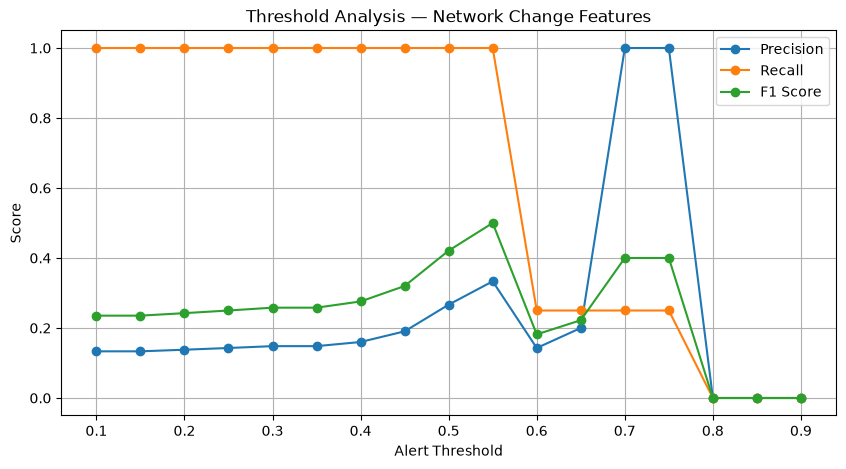

In [34]:
# Cell 34: Plot Threshold Metrics

plt.figure(figsize=(10, 5))

plt.plot(
    threshold_df["threshold"],
    threshold_df["precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_df["threshold"],
    threshold_df["recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_df["threshold"],
    threshold_df["f1"],
    marker="o",
    label="F1 Score"
)

plt.xlabel("Alert Threshold")
plt.ylabel("Score")
plt.title("Threshold Analysis — Network Change Features")
plt.legend()
plt.grid(True)
plt.show()

In [35]:
# Cell 35: Save Threshold Analysis

threshold_path = (
    PHASE17_DIR
    / "threshold_optimization.csv"
)

threshold_df.to_csv(
    threshold_path,
    index=False
)

print("Threshold analysis saved to:")
print(threshold_path)

Threshold analysis saved to:
C:\Users\ADMIN\FinGraph-Sentinel\data\results\phase17\threshold_optimization.csv


In [36]:
from sklearn.metrics import precision_score, recall_score, f1_score

def evaluate_thresholds(X_train, X_test, y_train, y_test, split_name):
    model = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("classifier", LogisticRegression(
            class_weight="balanced",
            max_iter=2000,
            random_state=42
        ))
    ])

    model.fit(X_train, y_train)
    probabilities = model.predict_proba(X_test)[:, 1]

    results = []

    for threshold in np.arange(0.10, 0.91, 0.05):
        predictions = (probabilities >= threshold).astype(int)

        results.append({
            "split": split_name,
            "threshold": round(threshold, 2),
            "predicted_alerts": int(predictions.sum()),
            "actual_events": int(y_test.sum()),
            "precision": precision_score(
                y_test, predictions, zero_division=0
            ),
            "recall": recall_score(
                y_test, predictions, zero_division=0
            ),
            "f1_score": f1_score(
                y_test, predictions, zero_division=0
            )
        })

    return pd.DataFrame(results)

In [37]:
network_features = feature_groups["Network_Change_Features"]

X_network = model_df[network_features].copy()

split_60 = int(len(model_df) * 0.60)
split_70 = int(len(model_df) * 0.70)

results_60 = evaluate_thresholds(
    X_network.iloc[:split_60],
    X_network.iloc[split_60:],
    y.iloc[:split_60],
    y.iloc[split_60:],
    "60_40"
)

results_70 = evaluate_thresholds(
    X_network.iloc[:split_70],
    X_network.iloc[split_70:],
    y.iloc[:split_70],
    y.iloc[split_70:],
    "70_30"
)

threshold_stability_df = pd.concat(
    [results_60, results_70],
    ignore_index=True
)

threshold_stability_df

,split,threshold,predicted_alerts,actual_events,precision,recall,f1_score
0,60_40,0.10,41,4,0.097561,1.00,0.177778
1,60_40,0.15,41,4,0.097561,1.00,0.177778
2,60_40,0.20,41,4,0.097561,1.00,0.177778
3,60_40,0.25,39,4,0.102564,1.00,0.186047
4,60_40,0.30,38,4,0.105263,1.00,0.190476
5,60_40,0.35,37,4,0.108108,1.00,0.195122
6,60_40,0.40,34,4,0.117647,1.00,0.210526
7,60_40,0.45,27,4,0.148148,1.00,0.258065
8,60_40,0.50,20,4,0.200000,1.00,0.333333
9,60_40,0.55,16,4,0.250000,1.00,0.400000


In [38]:
threshold_comparison = threshold_stability_df.pivot(
    index="threshold",
    columns="split",
    values="f1_score"
)

threshold_comparison

split,60_40,70_30
threshold,,
0.10,0.177778,0.235294
0.15,0.177778,0.235294
0.20,0.177778,0.242424
0.25,0.186047,0.250000
0.30,0.190476,0.258065
0.35,0.195122,0.258065
0.40,0.210526,0.275862
0.45,0.258065,0.320000
0.50,0.333333,0.421053


In [39]:
threshold_stability_path = (
    PHASE17_DIR / "threshold_stability_analysis.csv"
)

threshold_stability_df.to_csv(
    threshold_stability_path,
    index=False
)

print(f"Saved to: {threshold_stability_path}")

Saved to: C:\Users\ADMIN\FinGraph-Sentinel\data\results\phase17\threshold_stability_analysis.csv


In [40]:
from sklearn.base import clone

candidate_groups = {
    "Network_Change_Features": feature_groups["Network_Change_Features"],
    "Risk_Change_Features": feature_groups["Risk_Change_Features"],
    "Change_Features": feature_groups["Change_Features"],
    "All_Features": feature_groups["All_Features"]
}

walk_forward_results = []

for group_name, features in candidate_groups.items():

    X_group = model_df[features].copy()

    for window in window_definitions:

        train_end = int(len(model_df) * window["train_end"])
        test_end = int(len(model_df) * window["test_end"])

        X_train = X_group.iloc[:train_end]
        X_test = X_group.iloc[train_end:test_end]

        y_train = y.iloc[:train_end]
        y_test = y.iloc[train_end:test_end]

        if y_test.sum() == 0:
            continue

        model = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("classifier", LogisticRegression(
                class_weight="balanced",
                max_iter=2000,
                random_state=42
            ))
        ])

        model.fit(X_train, y_train)

        probabilities = model.predict_proba(X_test)[:, 1]
        predictions = (probabilities >= 0.55).astype(int)

        walk_forward_results.append({
            "feature_group": group_name,
            "window": window["name"],
            "train_observations": len(X_train),
            "test_observations": len(X_test),
            "test_events": int(y_test.sum()),
            "roc_auc": roc_auc_score(y_test, probabilities),
            "pr_auc": average_precision_score(y_test, probabilities),
            "precision": precision_score(
                y_test, predictions, zero_division=0
            ),
            "recall": recall_score(
                y_test, predictions, zero_division=0
            ),
            "f1_score": f1_score(
                y_test, predictions, zero_division=0
            )
        })

walk_forward_df = pd.DataFrame(walk_forward_results)

walk_forward_df

,feature_group,window,train_observations,test_observations,test_events,roc_auc,pr_auc,precision,recall,f1_score
0,Network_Change_Features,Window_2,61,16,1,0.866667,0.333333,0.142857,1.0,0.250000
1,Network_Change_Features,Window_3,72,15,4,0.863636,0.691667,0.571429,1.0,0.727273
2,Risk_Change_Features,Window_2,61,16,1,0.733333,0.200000,0.142857,1.0,0.250000
3,Risk_Change_Features,Window_3,72,15,4,0.840909,0.684524,0.571429,1.0,0.727273
4,Change_Features,Window_2,61,16,1,0.733333,0.200000,0.166667,1.0,0.285714
5,Change_Features,Window_3,72,15,4,0.840909,0.684524,0.500000,1.0,0.666667
6,All_Features,Window_2,61,16,1,0.800000,0.250000,0.111111,1.0,0.200000
7,All_Features,Window_3,72,15,4,0.568182,0.374242,0.333333,0.5,0.400000


In [41]:
candidate_model_summary = (
    walk_forward_df
    .groupby("feature_group")
    .agg(
        mean_roc_auc=("roc_auc", "mean"),
        mean_pr_auc=("pr_auc", "mean"),
        mean_precision=("precision", "mean"),
        mean_recall=("recall", "mean"),
        mean_f1=("f1_score", "mean"),
        evaluated_windows=("window", "count")
    )
    .sort_values("mean_pr_auc", ascending=False)
    .reset_index()
)

candidate_model_summary

,feature_group,mean_roc_auc,mean_pr_auc,mean_precision,mean_recall,mean_f1,evaluated_windows
0,Network_Change_Features,0.865152,0.512500,0.357143,1.00,0.488636,2
1,Change_Features,0.787121,0.442262,0.333333,1.00,0.476190,2
2,Risk_Change_Features,0.787121,0.442262,0.357143,1.00,0.488636,2
3,All_Features,0.684091,0.312121,0.222222,0.75,0.300000,2


In [42]:
walk_forward_path = (
    PHASE17_DIR / "candidate_model_walk_forward_comparison.csv"
)

summary_path = (
    PHASE17_DIR / "candidate_model_summary.csv"
)

walk_forward_df.to_csv(walk_forward_path, index=False)
candidate_model_summary.to_csv(summary_path, index=False)

print(f"Saved detailed results to: {walk_forward_path}")
print(f"Saved summary to: {summary_path}")

Saved detailed results to: C:\Users\ADMIN\FinGraph-Sentinel\data\results\phase17\candidate_model_walk_forward_comparison.csv
Saved summary to: C:\Users\ADMIN\FinGraph-Sentinel\data\results\phase17\candidate_model_summary.csv


In [43]:
final_feature_group = "Network_Change_Features"

final_features = feature_groups[final_feature_group]

final_threshold = 0.55

print("Final candidate configuration")
print(f"Feature group: {final_feature_group}")
print(f"Features: {final_features}")
print(f"Alert threshold: {final_threshold}")

Final candidate configuration
Feature group: Network_Change_Features
Features: ['degree_change', 'betweenness_change', 'pagerank_change']
Alert threshold: 0.55


In [44]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

X_final = model_df[final_features].copy()
y_final = model_df[target_column].astype(int).copy()

final_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(
        class_weight="balanced",
        max_iter=2000,
        random_state=42
    ))
])

final_model.fit(X_final, y_final)

print("Final candidate model trained successfully.")
print(f"Training observations: {len(X_final)}")
print(f"Positive events: {int(y_final.sum())}")

Final candidate model trained successfully.
Training observations: 103
Positive events: 15


In [45]:
import joblib

final_model_path = PHASE17_DIR / "final_candidate_model.joblib"

joblib.dump(final_model, final_model_path)

print(f"Model saved to: {final_model_path}")

Model saved to: C:\Users\ADMIN\FinGraph-Sentinel\data\results\phase17\final_candidate_model.joblib


In [46]:
import json

final_model_config = {
    "model_name": "Logistic Regression",
    "feature_group": final_feature_group,
    "features": final_features,
    "alert_threshold": final_threshold,
    "target_column": target_column,
    "training_observations": int(len(X_final)),
    "positive_events": int(y_final.sum()),
    "validation_method": "Chronological walk-forward evaluation",
    "status": "Provisional research candidate",
    "limitations": [
        "Only two chronological evaluation windows contained positive events",
        "Validation sample sizes were small",
        "Threshold was evaluated on limited historical events",
        "Further external and prospective validation is required"
    ]
}

config_path = PHASE17_DIR / "final_model_config.json"

with open(config_path, "w", encoding="utf-8") as file:
    json.dump(final_model_config, file, indent=4)

print(f"Configuration saved to: {config_path}")

Configuration saved to: C:\Users\ADMIN\FinGraph-Sentinel\data\results\phase17\final_model_config.json


In [47]:
integration_df = model_df[
    ["date"] + final_features
].copy()

integration_df["risk_probability"] = final_model.predict_proba(
    model_df[final_features]
)[:, 1]

integration_df["alert_threshold"] = final_threshold

integration_df["alert_status"] = np.where(
    integration_df["risk_probability"] >= final_threshold,
    "ALERT",
    "NORMAL"
)

integration_df = integration_df.sort_values("date").reset_index(drop=True)

integration_df.head()

,date,degree_change,betweenness_change,pagerank_change,risk_probability,alert_threshold,alert_status
0,2021-12-28,0.002833,0.000000,0.024208,0.509760,0.55,NORMAL
1,2022-02-09,0.018167,0.084375,-0.037917,0.585102,0.55,ALERT
2,2022-02-24,0.111875,0.011875,0.009167,0.706331,0.55,ALERT
3,2022-03-10,0.023417,-0.046250,-0.004167,0.438984,0.55,NORMAL
4,2022-03-24,0.043542,-0.051000,-0.002583,0.472550,0.55,NORMAL


In [48]:
integration_df["risk_category"] = pd.cut(
    integration_df["risk_probability"],
    bins=[-np.inf, 0.30, 0.55, 0.75, np.inf],
    labels=["Low", "Moderate", "High", "Critical"]
)

integration_df[
    [
        "date",
        "risk_probability",
        "alert_threshold",
        "alert_status",
        "risk_category"
    ]
].tail(10)

,date,risk_probability,alert_threshold,alert_status,risk_category
93,2026-01-22,0.600571,0.55,ALERT,High
94,2026-02-20,0.335756,0.55,NORMAL,Moderate
95,2026-03-06,0.463158,0.55,NORMAL,Moderate
96,2026-03-20,0.654226,0.55,ALERT,High
97,2026-05-04,0.523382,0.55,NORMAL,Moderate
98,2026-05-18,0.715237,0.55,ALERT,High
99,2026-06-02,0.161148,0.55,NORMAL,Low
100,2026-06-16,0.244421,0.55,NORMAL,Low
101,2026-07-01,0.471546,0.55,NORMAL,Moderate
102,2026-07-16,0.325438,0.55,NORMAL,Moderate


In [49]:
integration_path = (
    PHASE17_DIR / "phase18_risk_predictions.csv"
)

integration_df.to_csv(
    integration_path,
    index=False
)

print(f"Saved Phase 18 integration dataset to: {integration_path}")
print(f"Total records: {len(integration_df)}")
print(f"Alerts: {(integration_df['alert_status'] == 'ALERT').sum()}")

Saved Phase 18 integration dataset to: C:\Users\ADMIN\FinGraph-Sentinel\data\results\phase17\phase18_risk_predictions.csv
Total records: 103
Alerts: 33


In [50]:
print("Alert distribution:")
print(integration_df["alert_status"].value_counts())

print("\nRisk category distribution:")
print(integration_df["risk_category"].value_counts())

Alert distribution:
alert_status
NORMAL    70
ALERT     33
Name: count, dtype: int64

Risk category distribution:
risk_category
Moderate    55
High        31
Low         15
Critical     2
Name: count, dtype: int64


In [51]:
phase17_summary = {
    "phase": "Phase 17",
    "project": "FinGraph-Sentinel",
    "system": "Adaptive Regime-Aware Contagion Early-Warning System",
    "final_candidate_model": {
        "algorithm": "Logistic Regression",
        "feature_group": final_feature_group,
        "features": final_features,
        "alert_threshold": final_threshold
    },
    "dataset": {
        "observations": int(len(model_df)),
        "positive_events": int(y_final.sum()),
        "negative_events": int((y_final == 0).sum())
    },
    "walk_forward_results": {
        "network_change_mean_roc_auc": 0.865152,
        "network_change_mean_pr_auc": 0.512500,
        "network_change_mean_f1": 0.488636,
        "evaluated_windows": 2
    },
    "integration_output": {
        "total_records": int(len(integration_df)),
        "alerts": int(
            (integration_df["alert_status"] == "ALERT").sum()
        ),
        "normal_records": int(
            (integration_df["alert_status"] == "NORMAL").sum()
        ),
        "critical_records": int(
            (integration_df["risk_category"] == "Critical").sum()
        )
    },
    "limitations": [
        "Only two chronological evaluation windows contained positive events",
        "Validation sample sizes were small",
        "Threshold analysis used limited historical events",
        "Full-dataset predictions are intended for integration demonstration",
        "External and prospective validation is required"
    ],
    "phase18_files": [
        "phase18_risk_predictions.csv",
        "final_candidate_model.joblib",
        "final_model_config.json"
    ]
}

print(phase17_summary)

{'phase': 'Phase 17', 'project': 'FinGraph-Sentinel', 'system': 'Adaptive Regime-Aware Contagion Early-Warning System', 'final_candidate_model': {'algorithm': 'Logistic Regression', 'feature_group': 'Network_Change_Features', 'features': ['degree_change', 'betweenness_change', 'pagerank_change'], 'alert_threshold': 0.55}, 'dataset': {'observations': 103, 'positive_events': 15, 'negative_events': 88}, 'walk_forward_results': {'network_change_mean_roc_auc': 0.865152, 'network_change_mean_pr_auc': 0.5125, 'network_change_mean_f1': 0.488636, 'evaluated_windows': 2}, 'integration_output': {'total_records': 103, 'alerts': 33, 'normal_records': 70, 'critical_records': 2}, 'limitations': ['Only two chronological evaluation windows contained positive events', 'Validation sample sizes were small', 'Threshold analysis used limited historical events', 'Full-dataset predictions are intended for integration demonstration', 'External and prospective validation is required'], 'phase18_files': ['phase1

In [52]:
phase17_summary_path = PHASE17_DIR / "phase17_final_summary.json"

with open(phase17_summary_path, "w", encoding="utf-8") as file:
    json.dump(phase17_summary, file, indent=4)

print(f"Saved to: {phase17_summary_path}")

Saved to: C:\Users\ADMIN\FinGraph-Sentinel\data\results\phase17\phase17_final_summary.json


In [53]:
phase17_report = f"""# FinGraph-Sentinel — Phase 17 Final Summary

## Final Candidate Configuration

- Model: Logistic Regression
- Feature group: {final_feature_group}
- Features: {", ".join(final_features)}
- Alert threshold: {final_threshold}

## Dataset

- Observations: {len(model_df)}
- Positive events: {int(y_final.sum())}
- Negative events: {int((y_final == 0).sum())}

## Walk-Forward Evaluation

- Mean ROC-AUC: 0.865152
- Mean PR-AUC: 0.512500
- Mean F1 score: 0.488636
- Evaluated windows containing positive events: 2

## Integration Dataset

- Total records: {len(integration_df)}
- ALERT records: {(integration_df["alert_status"] == "ALERT").sum()}
- NORMAL records: {(integration_df["alert_status"] == "NORMAL").sum()}
- Critical risk records: {(integration_df["risk_category"] == "Critical").sum()}

## Limitations

1. Only two chronological evaluation windows contained positive events.
2. Validation sample sizes were small.
3. Threshold analysis used limited historical events.
4. Full-dataset predictions are intended for integration demonstration.
5. External and prospective validation is required.

## Phase 18 Preparation

The prediction dataset, trained model, and model configuration
have been saved for frontend integration.
"""

phase17_report_path = (
    PHASE17_DIR / "PHASE_17_FINAL_SUMMARY.md"
)

with open(phase17_report_path, "w", encoding="utf-8") as file:
    file.write(phase17_report)

print(f"Saved to: {phase17_report_path}")

Saved to: C:\Users\ADMIN\FinGraph-Sentinel\data\results\phase17\PHASE_17_FINAL_SUMMARY.md
